 Part A: Tabular Data

**Dataset:** Pima Indians Diabetes Dataset  
**Objective:** Data acquisition, cleaning, preprocessing and analysis on tabular medical data

In [1]:
import kagglehub

path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset")
print("Path to dataset files:", path)

/home/sambhav/miniconda3/envs/mlenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 9.13k/9.13k [00:00<00:00, 22.9MB/s]

Extracting files...
Path to dataset files: /home/sambhav/.cache/kagglehub/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/versions/1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
csv_file = os.path.join(path, 'diabetes.csv')
df = pd.read_csv(csv_file)
print(f"Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
5,5,116,74.0,27,102.5,25.6,0.201,30,0
6,3,78,50.0,32,88.0,31.0,0.248,26,1
7,10,115,70.0,27,102.5,35.3,0.134,29,0
8,2,197,70.0,45,543.0,30.5,0.158,53,1
9,8,125,96.0,32,169.5,34.3,0.232,54,1


In [5]:
print(f"Shape of dataset: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Shape of dataset: (768, 9)
Number of rows: 768
Number of columns: 9


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [7]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [10]:

implausible_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Checking for implausible zero values:")
print("-" * 45)
for col in implausible_cols:
    zero_count = (df[col] == 0).sum()
    pct = zero_count / len(df) * 100
    print(f"{col:20s}: {zero_count:4d} zeros ({pct:.1f}%)")

Checking for implausible zero values:
---------------------------------------------
Glucose             :    0 zeros (0.0%)
BloodPressure       :    0 zeros (0.0%)
SkinThickness       :    0 zeros (0.0%)
Insulin             :    0 zeros (0.0%)
BMI                 :    0 zeros (0.0%)


In [11]:

df_clean = df.copy()
df_clean[implausible_cols] = df_clean[implausible_cols].replace(0, np.nan)

print("Missing values after replacing implausible zeros:")
print(df_clean.isnull().sum())

Missing values after replacing implausible zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [12]:

missing = df_clean.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    plt.figure(figsize=(8, 4))
    missing.plot(kind='bar', color='salmon', edgecolor='black')
    plt.title('Missing Values Per Column')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found - dataset is already clean.")

No missing values found - dataset is already clean.


### Impute Missing Values
For healthcare data, we use **median** imputation (robust to outliers) instead of mean.

In [13]:

for col in implausible_cols:
    median_val = df_clean[col].median()
    null_count = df_clean[col].isnull().sum()
    df_clean[col].fillna(median_val, inplace=True)
    print(f"{col}: filled {null_count} NaNs with median = {median_val}")

print(f"\nRemaining missing values: {df_clean.isnull().sum().sum()}")

Glucose: filled 0 NaNs with median = 117.0
BloodPressure: filled 0 NaNs with median = 72.0
SkinThickness: filled 0 NaNs with median = 28.0
Insulin: filled 0 NaNs with median = 102.5
BMI: filled 0 NaNs with median = 32.05

Remaining missing values: 0


### Check for Outliers

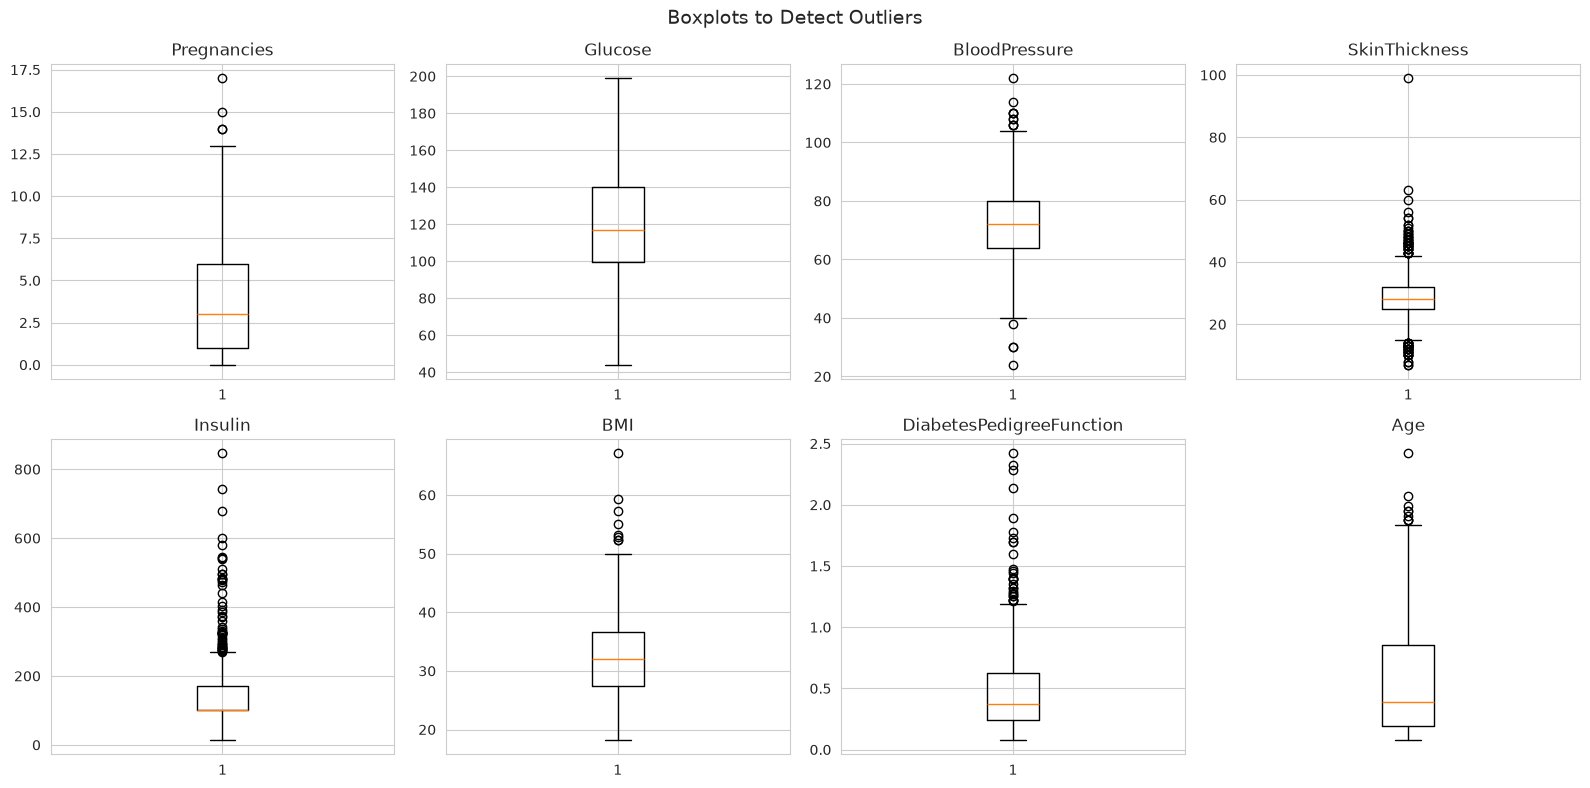

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df_clean.columns[:-1]):
    axes[i].boxplot(df_clean[col])
    axes[i].set_title(col)

axes[-1].axis('off')
plt.suptitle('Boxplots to Detect Outliers', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:

df_no_outlier = df_clean.copy()

for col in df_no_outlier.columns[:-1]:
    Q1 = df_no_outlier[col].quantile(0.25)
    Q3 = df_no_outlier[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df_no_outlier[col] < lower) | (df_no_outlier[col] > upper)).sum()
    if outliers > 0:
        df_no_outlier[col] = df_no_outlier[col].clip(lower, upper)
        print(f"{col}: {outliers} outliers capped to [{lower:.1f}, {upper:.1f}]")

Pregnancies: 4 outliers capped to [-6.5, 13.5]
BloodPressure: 14 outliers capped to [40.0, 104.0]
SkinThickness: 87 outliers capped to [14.5, 42.5]
Insulin: 51 outliers capped to [2.0, 270.0]
BMI: 8 outliers capped to [13.8, 50.2]
DiabetesPedigreeFunction: 29 outliers capped to [-0.3, 1.2]
Age: 9 outliers capped to [-1.5, 66.5]


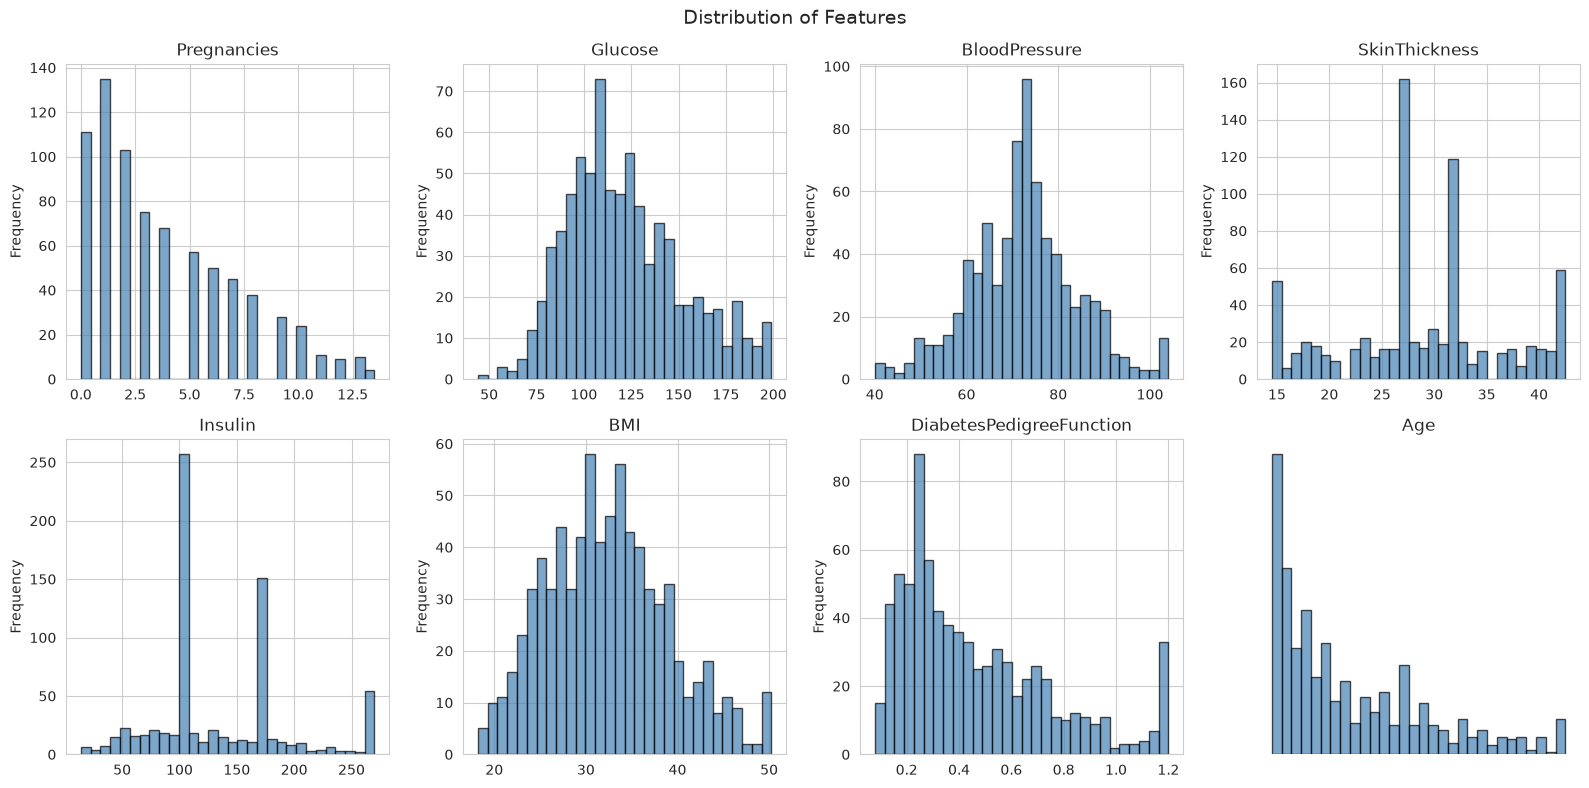

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df_no_outlier.columns[:-1]):
    axes[i].hist(df_no_outlier[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')
plt.suptitle('Distribution of Features', fontsize=14)
plt.tight_layout()
plt.show()

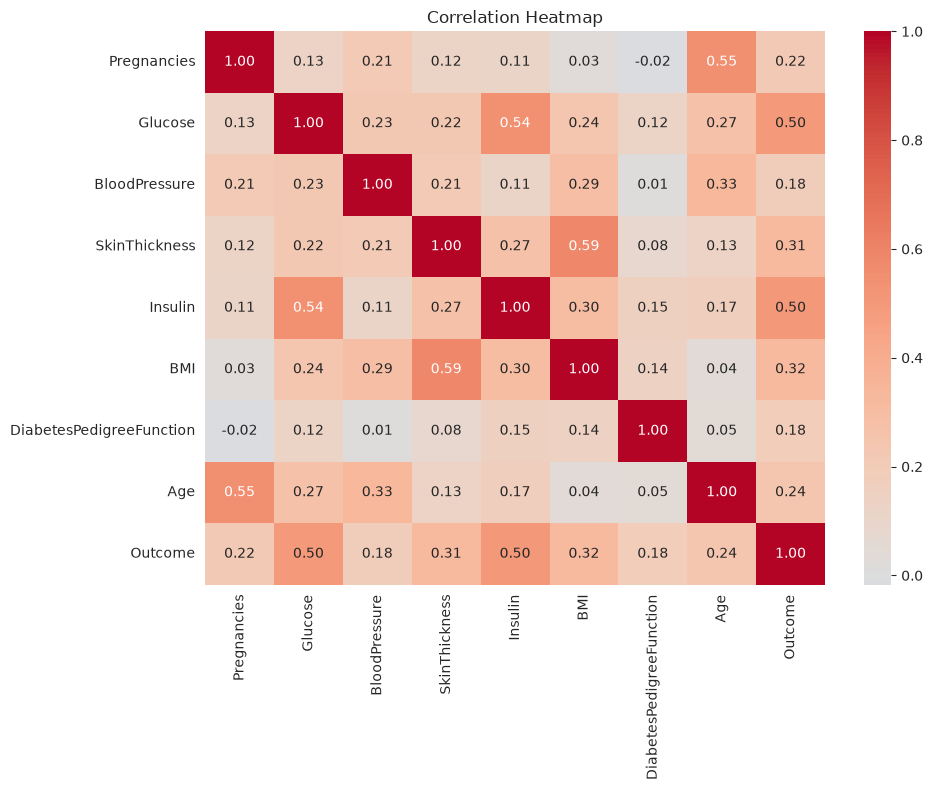

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_no_outlier.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Target variable distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Imbalance ratio: 1.87:1


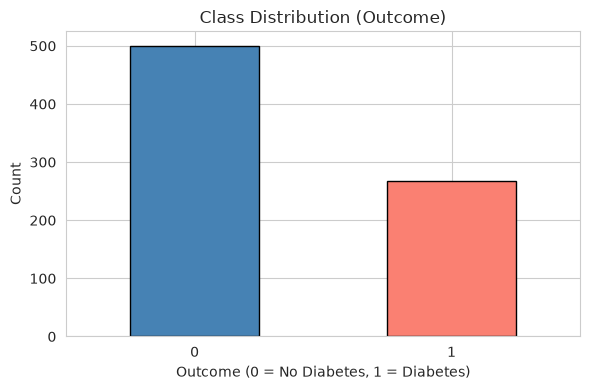

In [18]:
print("Target variable distribution:")
print(df_no_outlier['Outcome'].value_counts())
print(f"\nImbalance ratio: {df_no_outlier['Outcome'].value_counts()[0] / df_no_outlier['Outcome'].value_counts()[1]:.2f}:1")

plt.figure(figsize=(6, 4))
df_no_outlier['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Class Distribution (Outcome)')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

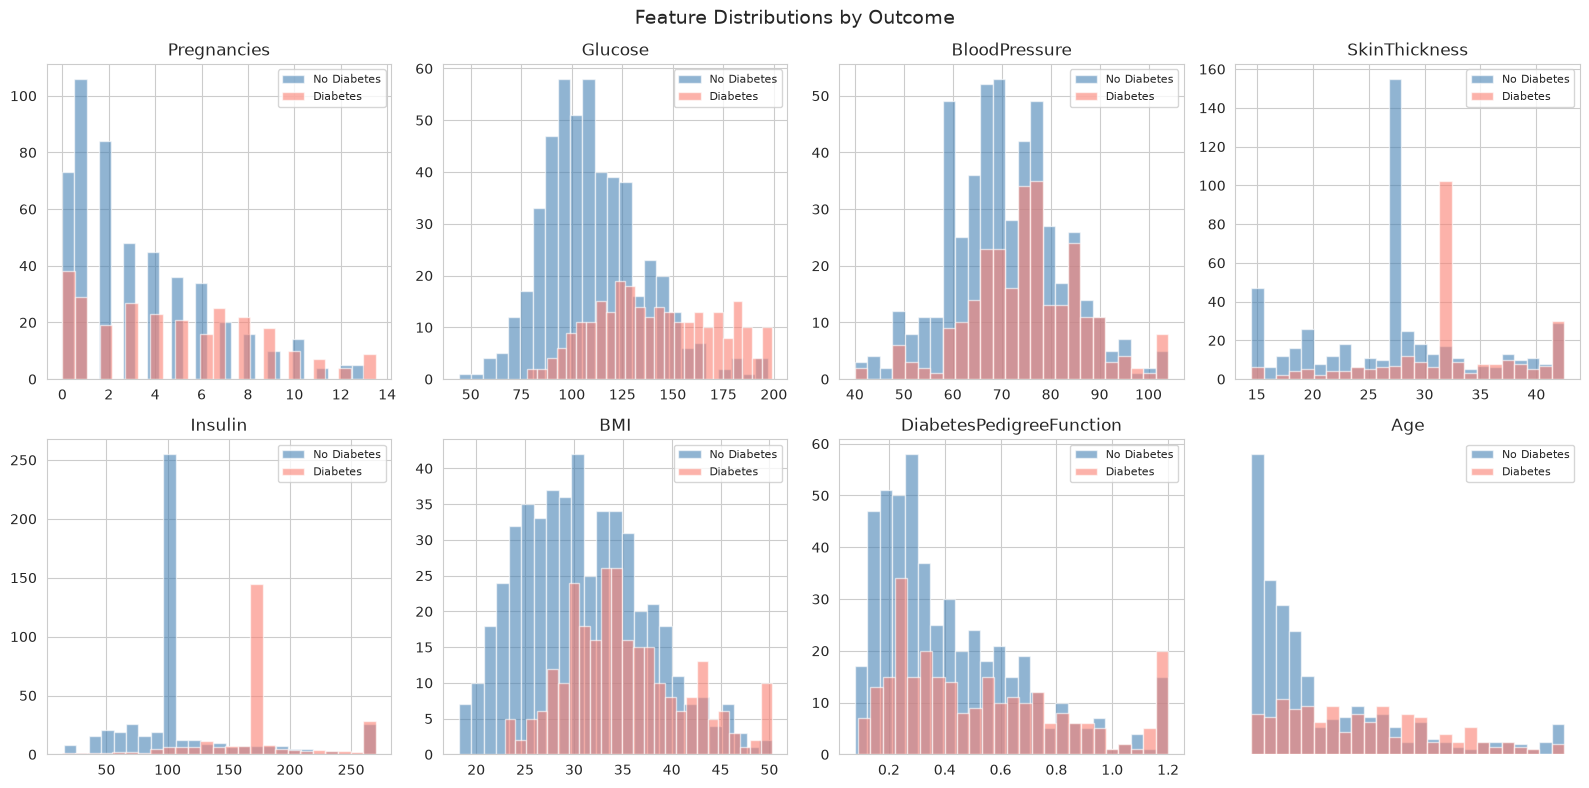

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df_no_outlier.columns[:-1]):
    df_no_outlier[df_no_outlier['Outcome'] == 0][col].hist(ax=axes[i], bins=25, alpha=0.6, label='No Diabetes', color='steelblue')
    df_no_outlier[df_no_outlier['Outcome'] == 1][col].hist(ax=axes[i], bins=25, alpha=0.6, label='Diabetes', color='salmon')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Feature Distributions by Outcome', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
from scipy import stats

glucose_diabetic = df_no_outlier[df_no_outlier['Outcome'] == 1]['Glucose']
glucose_non_diabetic = df_no_outlier[df_no_outlier['Outcome'] == 0]['Glucose']

t_stat, p_value = stats.ttest_ind(glucose_diabetic, glucose_non_diabetic)

print("Two-sample t-test: Glucose levels by Outcome")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"\nAt alpha=0.05: {'Reject H0 (significant difference)' if p_value < 0.05 else 'Fail to reject H0'}")

Two-sample t-test: Glucose levels by Outcome
t-statistic: 15.8090
p-value: 0.000000

At alpha=0.05: Reject H0 (significant difference)


In [21]:
# Bin pregnancies into categories
df_no_outlier['Preg_Category'] = pd.cut(df_no_outlier['Pregnancies'], 
                                         bins=[-1, 2, 5, 10, 20], 
                                         labels=['Low', 'Medium', 'High', 'Very High'])

contingency = pd.crosstab(df_no_outlier['Preg_Category'], df_no_outlier['Outcome'])
print("Contingency Table:")
print(contingency)

chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"p-value: {p_val_chi:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"\nAt alpha=0.05: {'Reject H0 (associated)' if p_val_chi < 0.05 else 'Fail to reject H0 (independent)'}")

Contingency Table:
Outcome          0   1
Preg_Category         
Low            263  86
Medium         129  71
High            94  91
Very High       14  20

Chi-square statistic: 41.3890
p-value: 0.000000
Degrees of freedom: 3

At alpha=0.05: Reject H0 (associated)


In [22]:
groups = [group['BMI'].values for name, group in df_no_outlier.groupby('Preg_Category')]

f_stat, p_val_anova = stats.f_oneway(*groups)

print("One-way ANOVA: BMI across Pregnancy categories")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val_anova:.6f}")
print(f"\nAt alpha=0.05: {'Reject H0 (means differ)' if p_val_anova < 0.05 else 'Fail to reject H0 (same means)'}")

One-way ANOVA: BMI across Pregnancy categories
F-statistic: 3.0028
p-value: 0.029808

At alpha=0.05: Reject H0 (means differ)


In [23]:
# Drop the temporary category column
df_no_outlier.drop('Preg_Category', axis=1, inplace=True)

In [24]:
df_feat = df_no_outlier.copy()

# BMI Category
df_feat['BMI_Category'] = pd.cut(df_feat['BMI'], 
                                  bins=[0, 18.5, 25, 30, 100], 
                                  labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Age Group
df_feat['Age_Group'] = pd.cut(df_feat['Age'], 
                               bins=[0, 30, 45, 60, 100], 
                               labels=['Young', 'Middle', 'Senior', 'Elderly'])

# Glucose-Insulin interaction
df_feat['Glucose_Insulin_Ratio'] = df_feat['Glucose'] / (df_feat['Insulin'] + 1)

# BMI * Age interaction
df_feat['BMI_Age'] = df_feat['BMI'] * df_feat['Age']

print("New features created:")
print(df_feat[['BMI_Category', 'Age_Group', 'Glucose_Insulin_Ratio', 'BMI_Age']].head())

New features created:
  BMI_Category Age_Group  Glucose_Insulin_Ratio  BMI_Age
0        Obese    Senior               0.868035   1680.0
1   Overweight    Middle               0.821256    824.6
2       Normal    Middle               1.073314    745.6
3   Overweight     Young               0.936842    590.1
4        Obese    Middle               0.810651   1422.3


Correlation with Outcome:
Insulin                     0.500678
Glucose                     0.495990
BMI_Age                     0.364875
BMI                         0.316460
SkinThickness               0.313945
Age                         0.242702
Pregnancies                 0.220392
DiabetesPedigreeFunction    0.184969
BloodPressure               0.178008
Glucose_Insulin_Ratio      -0.163498
Name: Outcome, dtype: float64


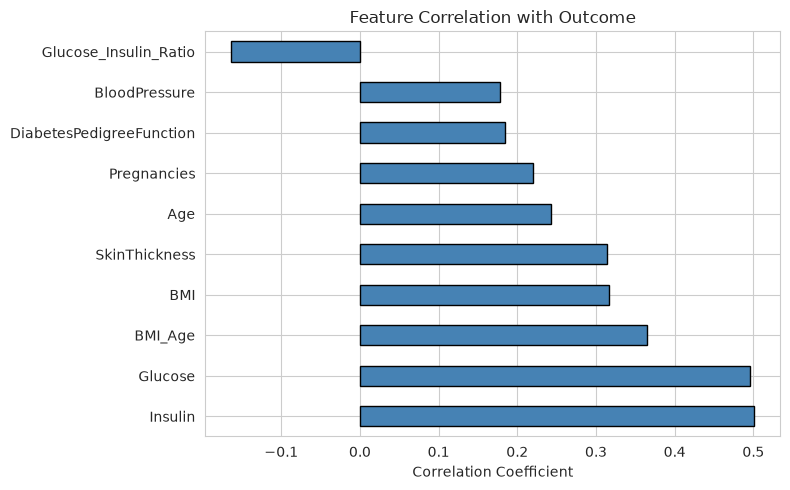

In [25]:

numeric_df = df_feat.select_dtypes(include=[np.number])


corr_with_target = numeric_df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
print("Correlation with Outcome:")
print(corr_with_target)

plt.figure(figsize=(8, 5))
corr_with_target.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Correlation with Outcome')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [26]:
# Select top features based on correlation threshold
selected_features = corr_with_target[abs(corr_with_target) > 0.1].index.tolist()
print(f"Selected features (|corr| > 0.1): {selected_features}")

Selected features (|corr| > 0.1): ['Insulin', 'Glucose', 'BMI_Age', 'BMI', 'SkinThickness', 'Age', 'Pregnancies', 'DiabetesPedigreeFunction', 'BloodPressure', 'Glucose_Insulin_Ratio']


In [27]:
from sklearn.preprocessing import StandardScaler

# Prepare final feature matrix
X = df_feat[selected_features].values
y = df_feat['Outcome'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (768, 10)
Target vector shape: (768,)


In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data statistics:")
print(f"Mean (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std  (should be ~1): {X_scaled.std(axis=0).round(4)}")

Scaled data statistics:
Mean (should be ~0): [ 0.  0. -0. -0. -0.  0. -0. -0.  0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [29]:

X_tensor = np.array(X_scaled, dtype=np.float32)
y_tensor = np.array(y, dtype=np.float32)

print(f"Final X tensor: {X_tensor.shape}, dtype={X_tensor.dtype}")
print(f"Final y tensor: {y_tensor.shape}, dtype={y_tensor.dtype}")
print(f"\nSample of scaled features (first 3 rows):")
print(X_tensor[:3])

Final X tensor: (768, 10), dtype=float32
Final y tensor: (768,), dtype=float32

Sample of scaled features (first 3 rows):
[[ 0.62689555  0.86462486  1.386854    0.1840336   0.81433666  1.445691
   0.6471497   0.5889273  -0.03082922 -0.30166745]
 [-0.52656    -1.2047266  -0.58287305 -0.8656902   0.02008048 -0.189304
  -0.84897    -0.37810147 -0.5436849  -0.37123266]
 [ 0.62689555  2.0142646  -0.7647861  -1.3605599   0.41720858 -0.10325164
   1.2455975   0.7465951  -0.7146368   0.00360195]]
